# Session 4 — Filters & Convolution
**George Hanna** · Computer Vision & Speech Recognition (EADA) · MILK10k

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

from milk10k import config      # where the MILK10k images are (config.IMG_DIR)

np.set_printoptions(precision=1, suppress=True)

## One window: patch → products → sum
5×5 toy image (100 = skin, 10 = lesion) and a 3×3 box-blur kernel.

In [2]:
image = np.array([[100, 100, 100, 100, 100],
                  [100, 100, 100, 100, 100],
                  [100, 100,  10,  10,  10],
                  [100, 100,  10,  10,  10],
                  [100, 100,  10,  10,  10]], dtype=float)
kernel = np.ones((3, 3)) / 9            # box blur

patch = image[1:4, 1:4]                 # window at (1, 1)
products = patch * kernel
print(products)
print(products.sum())

[[11.1 11.1 11.1]
 [11.1  1.1  1.1]
 [11.1  1.1  1.1]]
60.0


In [3]:
def conv_step(image, kernel, row, col):
    """one window: patch -> products -> sum"""
    k = kernel.shape[0]
    patch = image[row:row + k, col:col + k]
    products = patch * kernel
    return patch, products, products.sum()


# position of the window (0, 0)
conv_step(image, kernel, 0, 0)

(array([[100., 100., 100.],
        [100., 100., 100.],
        [100., 100.,  10.]]),
 array([[11.1, 11.1, 11.1],
        [11.1, 11.1, 11.1],
        [11.1, 11.1,  1.1]]),
 np.float64(90.0))

## Sliding the kernel

[[90. 80. 70.]
 [80. 60. 40.]
 [70. 40. 10.]]


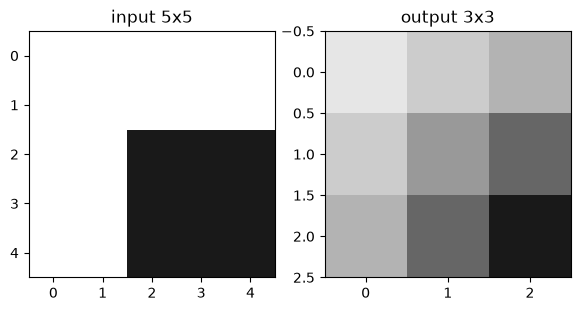

In [4]:
# 5x5 input image, 3x3 kernel -> 3x3 output
n_out = image.shape[0] - kernel.shape[0] + 1
output = np.zeros((n_out, n_out))
for row in range(n_out):
    for col in range(n_out):
        patch, products, total = conv_step(image, kernel, row, col)
        output[row, col] = total
print(output)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.2))
axs[0].imshow(image, cmap="gray", vmin=0, vmax=100)
axs[0].set_title("input 5x5")
axs[1].imshow(output, cmap="gray", vmin=0, vmax=100)
axs[1].set_title("output 3x3")
plt.show()

## Padding and stride

In [5]:
def output_size(n, k, padding=0, stride=1):
    return (n + 2*padding - k) // stride + 1


# input 5x5; k 3x3, padding 0, stride 2
print(output_size(5, 3, 0, 2))

2


## conv2d

In [6]:
def conv2d(image, kernel, padding=0, stride=1, pad_mode="constant"):
    k = kernel.shape[0]
    padded = np.pad(image, padding, mode=pad_mode)           # "constant" = zeros, "symmetric" = mirror
    out_h = output_size(image.shape[0], k, padding, stride)
    out_w = output_size(image.shape[1], k, padding, stride)
    out = np.zeros((out_h, out_w))
    for row in range(out_h):
        for col in range(out_w):
            patch, products, total = conv_step(padded, kernel, row*stride, col*stride)
            out[row, col] = total
    return out


conv2d(image, kernel, padding=0, stride=1)

array([[90., 80., 70.],
       [80., 60., 40.],
       [70., 40., 10.]])

In [7]:
print("padding 1, zeros:\n", conv2d(image, kernel, padding=1, stride=1))
print("padding 1, mirror:\n", conv2d(image, kernel, padding=1, stride=1, pad_mode="symmetric"))
print("stride 2:\n", conv2d(image, kernel, padding=0, stride=2))

padding 1, zeros:
 [[44.4 66.7 66.7 66.7 44.4]
 [66.7 90.  80.  70.  46.7]
 [66.7 80.  60.  40.  26.7]
 [66.7 70.  40.  10.   6.7]
 [44.4 46.7 26.7  6.7  4.4]]
padding 1, mirror:
 [[100. 100. 100. 100. 100.]
 [100.  90.  80.  70.  70.]
 [100.  80.  60.  40.  40.]
 [100.  70.  40.  10.  10.]
 [100.  70.  40.  10.  10.]]
stride 2:
 [[90. 70.]
 [70. 10.]]


## Kernels

In [8]:
KERNELS = {
    "identity": np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=float),
    "box_blur": np.ones((3, 3)) / 9,
    "gaussian": np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16,
    "sharpen":  np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=float),
    "outline":  np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=float),
    "emboss":   np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=float),
    "sobel_x":  np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float),
    "sobel_y":  np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float),
}

# each kernel on the 5x5 toy image
for name, k in KERNELS.items():
    print(name, "\n", conv2d(image, k))

identity 
 [[100. 100. 100.]
 [100.  10.  10.]
 [100.  10.  10.]]
box_blur 
 [[90. 80. 70.]
 [80. 60. 40.]
 [70. 40. 10.]]
gaussian 
 [[94.4 83.1 77.5]
 [83.1 49.4 32.5]
 [77.5 32.5 10. ]]
sharpen 
 [[ 100.  190.  190.]
 [ 190. -170.  -80.]
 [ 190.  -80.   10.]]
outline 
 [[  90.  180.  270.]
 [ 180. -450. -270.]
 [ 270. -270.    0.]]
emboss 
 [[ -80. -170. -170.]
 [-170. -350. -260.]
 [-170. -260.   10.]]
sobel_x 
 [[ -90.  -90.    0.]
 [-270. -270.    0.]
 [-360. -360.    0.]]
sobel_y 
 [[ -90. -270. -360.]
 [ -90. -270. -360.]
 [   0.    0.    0.]]


## Kernels on a real lesion
Lesion id: **ISIC_0073863** (dermoscopic, Reed nevus, benign), in grayscale.

(450, 600)


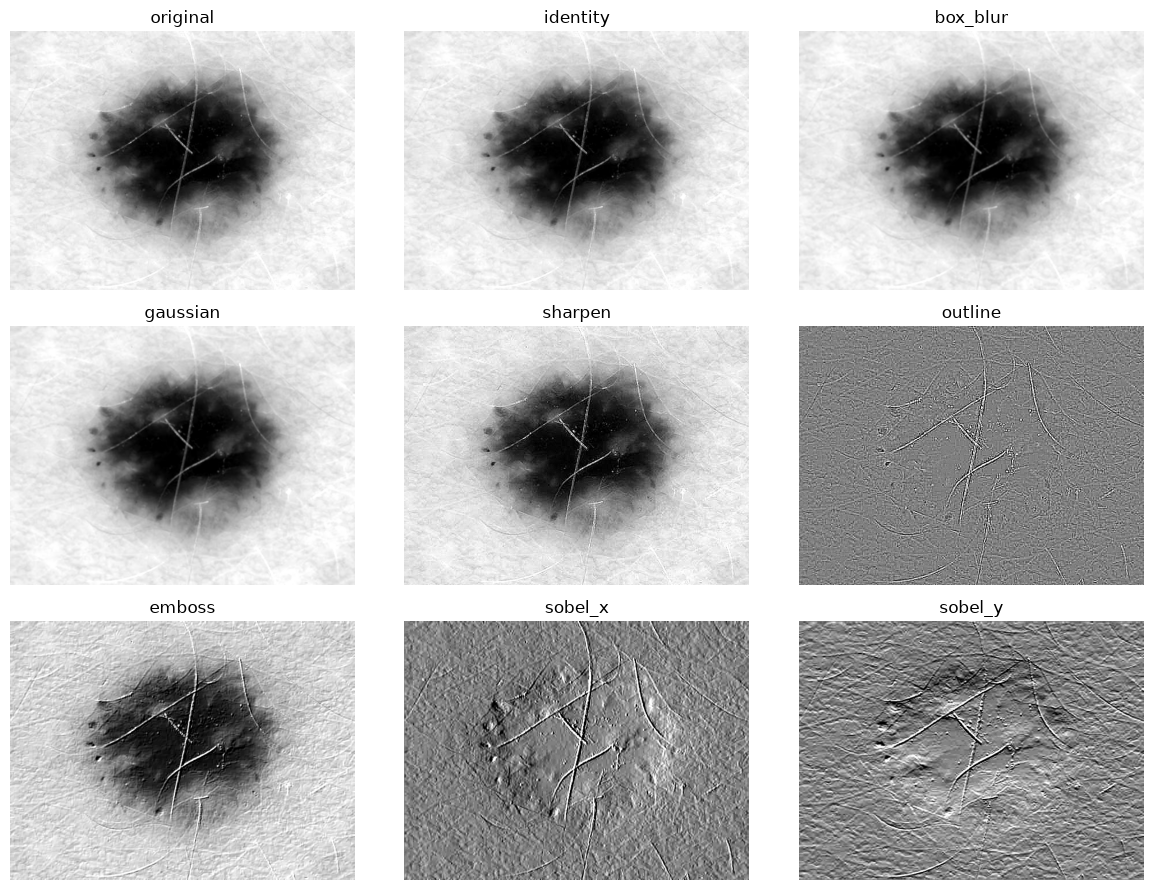

In [9]:
LESION_ID = "ISIC_0073863"
image = np.asarray(Image.open(config.IMG_DIR / f"{LESION_ID}.jpg").convert("L"), dtype=float)
print(image.shape)      # from here on, image is the lesion


def fast_conv2d(image, kernel):
    """Same as conv2d(..., padding=1, pad_mode="symmetric") but in optimized C."""
    return ndimage.correlate(image, kernel, mode="reflect")


results = {name: fast_conv2d(image, k) for name, k in KERNELS.items()}

fig, axs = plt.subplots(3, 3, figsize=(12, 9))
panels = [("original", image)] + list(results.items())
for ax, (name, img) in zip(axs.ravel(), panels):
    lo, hi = np.percentile(img, [1, 99])     # ignore the most extreme 1% at each end (slide 25)
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Loops vs. SciPy

In [10]:
t0 = time.perf_counter()
slow = conv2d(image, KERNELS["box_blur"], padding=1, pad_mode="symmetric")
t_slow = time.perf_counter() - t0

t0 = time.perf_counter()
fast = fast_conv2d(image, KERNELS["box_blur"])
t_fast = time.perf_counter() - t0

print(f"loops {t_slow:.3f}s | scipy {t_fast:.4f}s | {t_slow / t_fast:.0f}x faster")
print("same result:", np.allclose(slow, fast))

loops 0.323s | scipy 0.0014s | 226x faster
same result: True
